# Clustering and Unsupervised Learning

In today's session we are going to learn about clustering and unsupervised learning. We will be using the KMeans algorithm to cluster the data. We will also learn about the elbow method to find the optimal number of clusters.

## What is Clustering?
Clustering is a type of unsupervised learning. It is the task of grouping a set of objects in such a way that objects in the same group (or cluster) are more similar to each other than to those in other groups (clusters). It is unsupervised because the data is not labeled, the algorithm tries to find patterns in the data.

Uses of clustering include:
- Customer segmentation
- Thematic analysis
- Anomaly detection
- Image segmentation
- etc.

## KMeans Algorithm

KMeans is a popular and conceptually simple algorithm for clustering. It is an iterative algorithm that divides a group of n datasets into k subgroups (clusters) based on the similarity and their mean. The similarity is measured using the Euclidean distance between the data points (just think "distance"). The algorithm works for any number of dimensions, but we will focus on 1, 2, and 3 dimensions for visualization purposes and to help cement the concepts.

The algorithm works as follows:
1. Randomly select `k` data points as the initial centroids of the clusters.
   1. Centroids means a "center" point of a cluster. Though at this stage they are just random points.
   2. There are a number of different ways to initialize the centroids (e.g. random, k-means++, etc.)
   3. The number of clusters (k) is a given though we can identify an optimal k.
2. Assign each data point to the nearest centroid.
3. Recalculate the centroids of the clusters by taking the mean of all the data points assigned to each centroid.
4. Repeat steps 2 and 3 until the centroids do not change or the maximum number of iterations is reached.

Since the algorithm is iterative, the final clusters may depend on the initial centroids. To mitigate this, the algorithm is often run multiple times with different initial centroids and the best result is chosen. A result is considered "best" if the sum of squared distances from each point to its assigned cluster centroid is minimized.

Lucky we got computers to do this for us!

## Elbow Method

We can use the elbow method to find the optimal number of clusters. The idea is to run the KMeans algorithm for a range of k values and plot the sum of squared distances from each point to its assigned cluster centroid. The elbow point is the point where the sum of squared distances starts to level off. This is the optimal number of clusters. We will see how to do this a bit later on. But keep in mind that you can use your understanding of the data to choose the number of clusters.

## Parameter scaling

It is important to note that the scale of each parameter or feature (the min and max values) can affect the clustering. For example, if one feature has a range of 0-1 and another has a range of 0-1000, the clustering will be biased towards the feature with the larger range (as its impact on the distance between any two points will be orders of magnitude greater). To mitigate this, it is common to scale the features. We will see an example of this later.

##  Outline

1. Introduction to Clustering and K-Means
2. Setup and Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Introduction to K-Means Parameters
6. Determining the Number of Clusters
7. Applying K-Means Clustering
8. Visualizing the Clusters
9. Cluster Analysis
10. Workshop Challenges
11. Conclusions


## Let's get started!

We'll start by importing the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans # Let you guess..
from sklearn.preprocessing import StandardScaler # Will be used to scale data if required

> If you don't have sklearn installed you can use the code in the cell below to install it.
> 

In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_csv('Mall_Customers.csv')
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print("Dataset shape:", df.shape)
df.describe()


Dataset shape: (200, 5)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


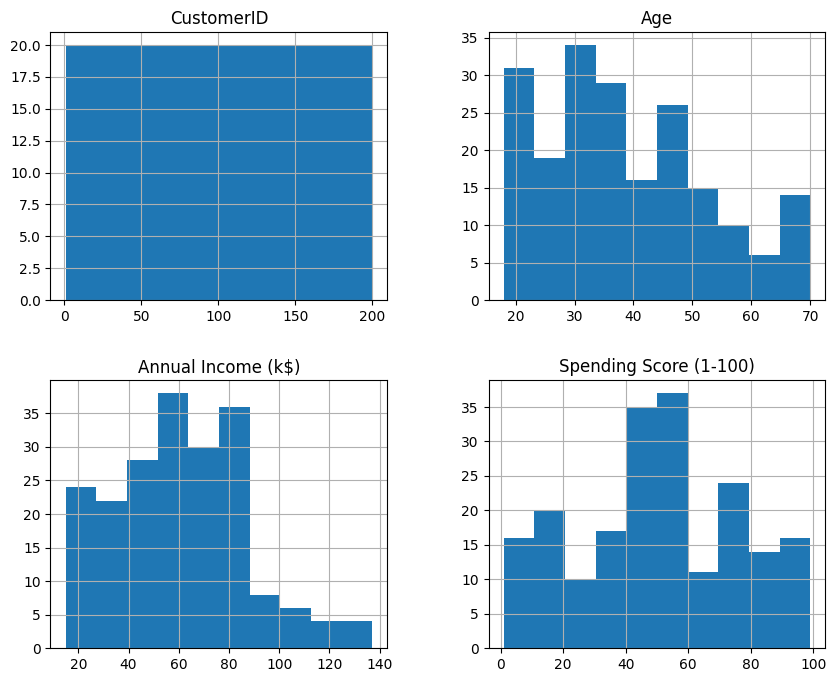

In [6]:
df.hist(figsize=(10, 8))
plt.show()


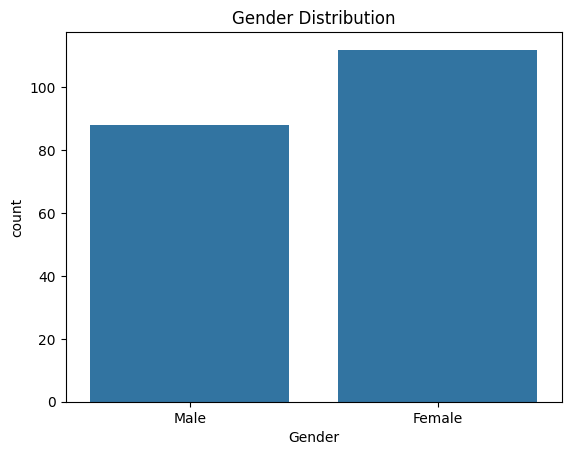

In [7]:
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

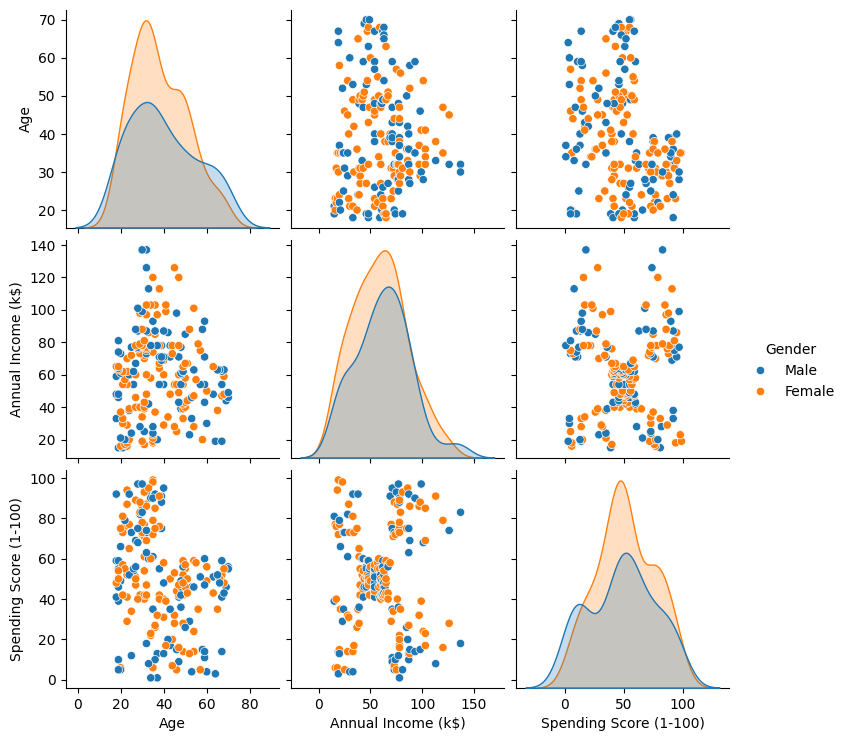

In [8]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)','Gender']], hue='Gender')
plt.show()

In [9]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


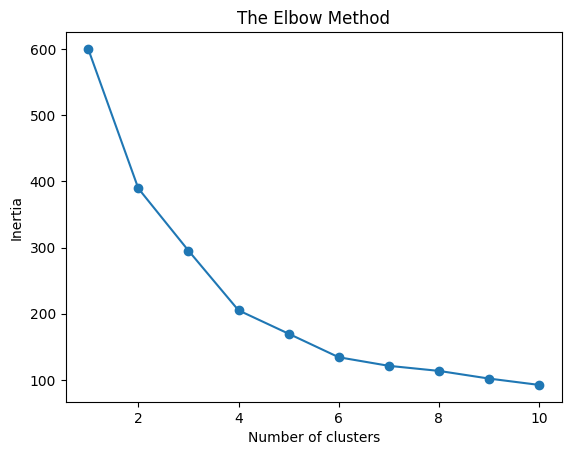

In [10]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show()


In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(features_scaled)
df['Cluster'] = kmeans.labels_


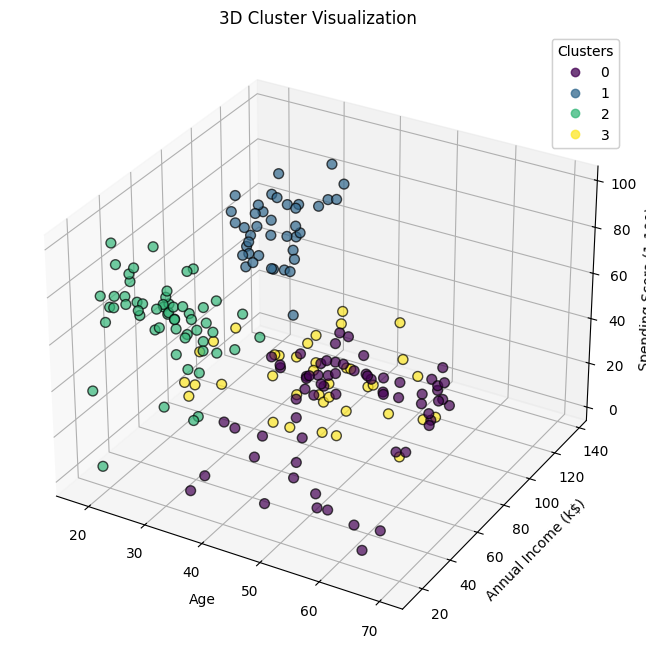

In [13]:
# 3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
                     c=df['Cluster'], cmap='viridis', edgecolor='k', alpha=0.7, s=50)

# Legend with cluster labels
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

# Labels and title
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('3D Cluster Visualization')

# Show plot
plt.show()


### Failures

If you are interested - this is a failed attempt of mine to do a cluster analysis and check its fit with the data labels..

In [14]:
iris = sns.load_dataset('iris') # built in sample dataset


In [15]:
iris.head() # just a dataframe with 5 columns

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


This of the `species` column as the "true" clusters. We will use the KMeans algorithm to cluster the data and compare the results with the true clusters.

## Exploratory Data Analysis


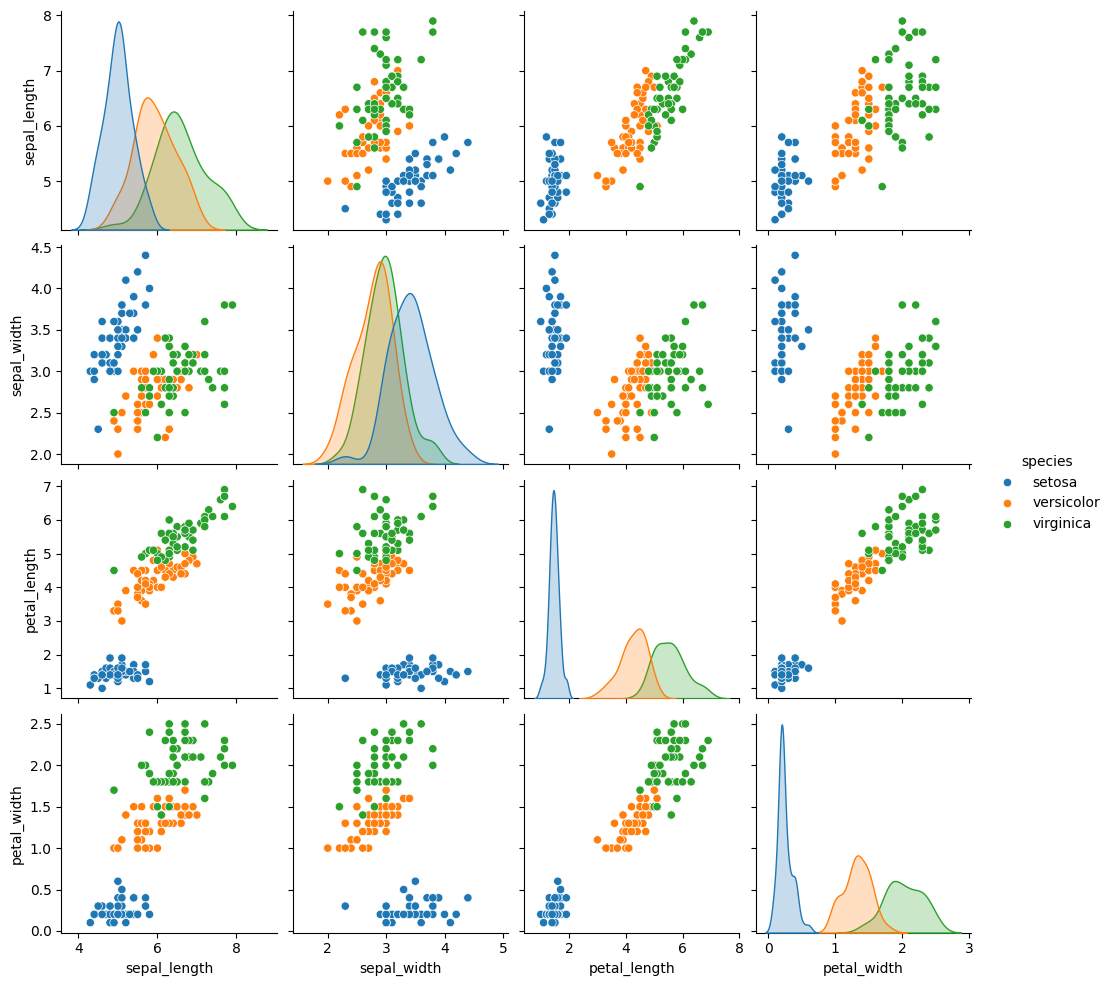

In [16]:
sns.pairplot(iris, hue='species')
plt.show()



Notice that the degree of separation between the species is not the same for all pairs of features. This is a good indication that clustering might be useful. But be aware, that scaling my partially bias where the clusters are formed. Let's try and scale the data and see if it makes a difference. 



In [18]:
from sklearn.preprocessing import StandardScaler

# Create an instance of StandardScaler
scaler = StandardScaler()

# Scale the numeric columns of the iris dataset
iris_scaled = iris.copy()  # Make a copy of the original dataset
iris_scaled[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']] = scaler.fit_transform(iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

# Print the scaled dataset


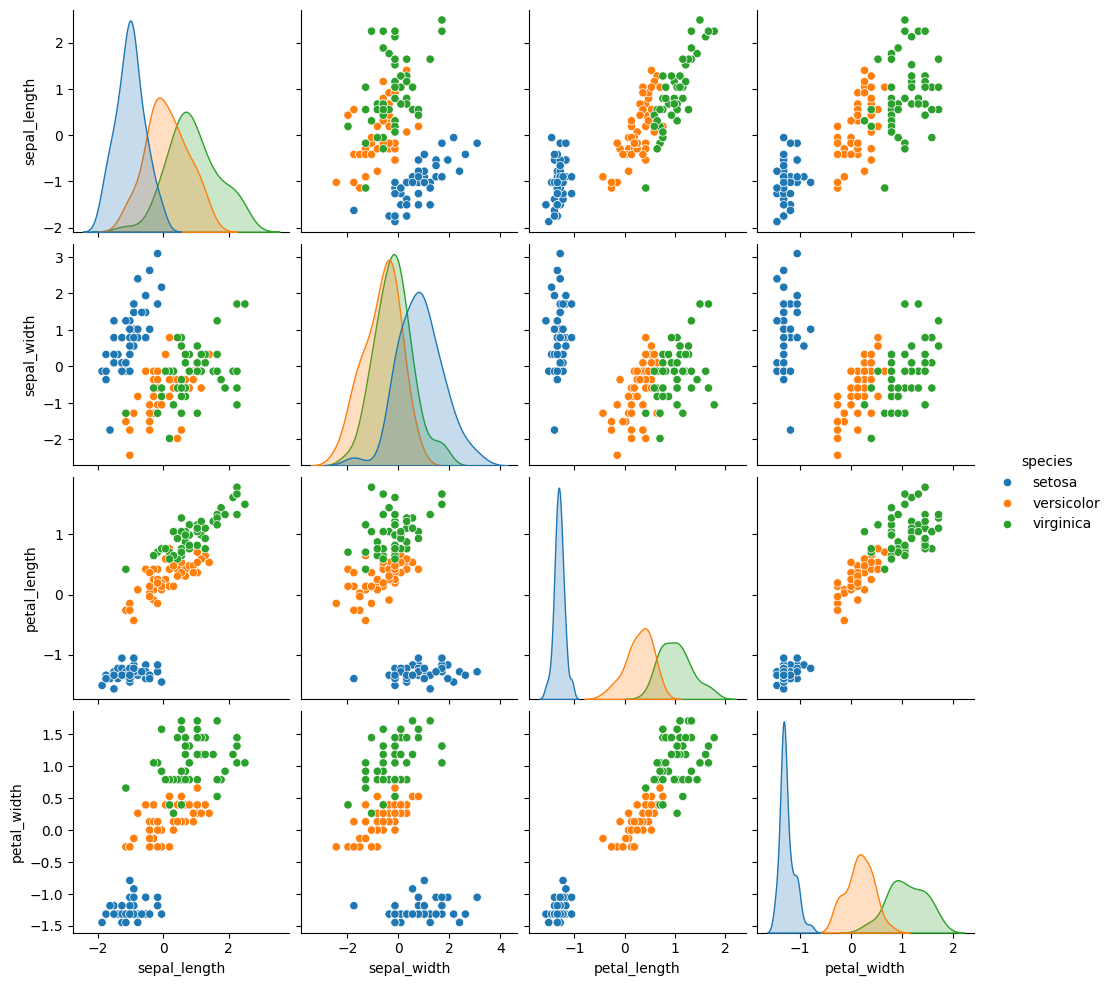

In [19]:
sns.pairplot(iris_scaled, hue='species')
plt.show()

They are identical! This is because seaborn's pairplot function scales the data for us. But it is good to know how to do it manually. Below, I have compared what the scaled versus unscaled representation looks like:


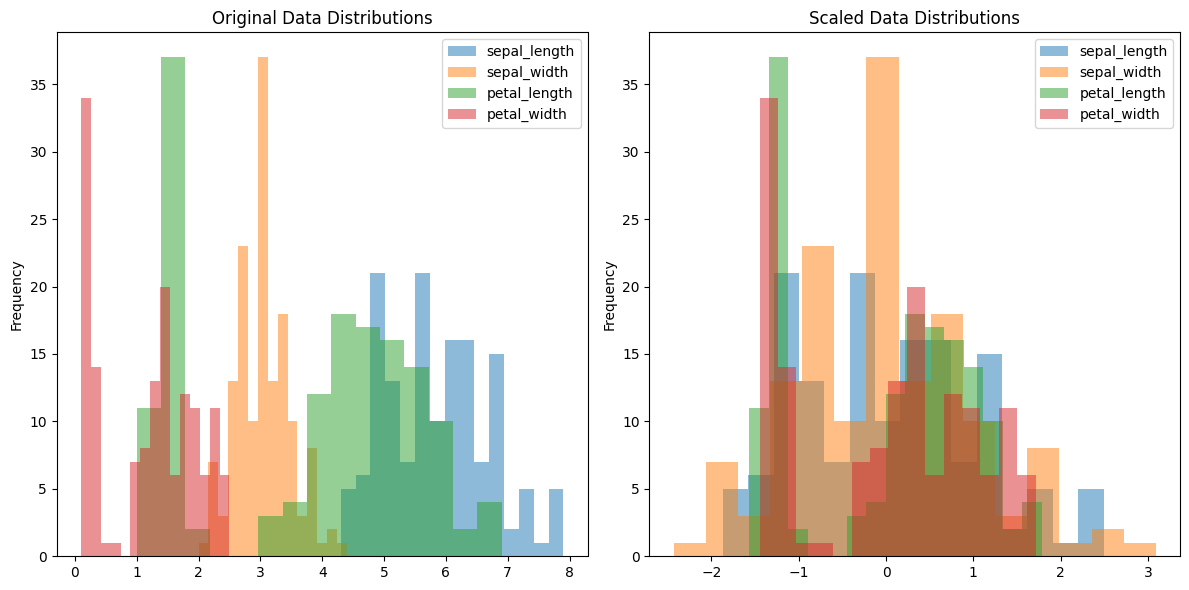

In [21]:
iris = sns.load_dataset('iris')
scaler = StandardScaler()

# Standardize the data
iris_scaled = scaler.fit_transform(iris.iloc[:, :-1])
iris_scaled = pd.DataFrame(iris_scaled, columns=iris.columns[:-1])

# Setup figure and axes
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plotting histograms for original data
for col in iris.columns[:-1]:
    iris[col].plot(kind='hist', bins=15, ax=axes[0], alpha=0.5, title='Original Data Distributions')
axes[0].legend(iris.columns[:-1])

# Plotting histograms for scaled data
for col in iris_scaled.columns:
    iris_scaled[col].plot(kind='hist', bins=15, ax=axes[1], alpha=0.5, title='Scaled Data Distributions')
    
axes[1].legend(iris_scaled.columns)

# Adjust the layout to prevent overlap
fig.tight_layout()

# Show plot
plt.show()


In [22]:
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

iris = sns.load_dataset('iris')
X = iris.drop('species', axis=1)
y = iris['species']


In [23]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [24]:
# Specify the number of clusters (3 species in the Iris dataset)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Cluster labels
clusters = kmeans.labels_


Accuracy of K-Means clustering: 0.67
[[50  0  0]
 [ 4  0 46]
 [ 0  0 50]]


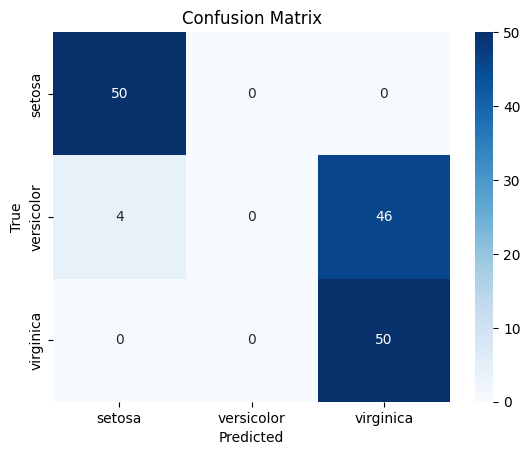

In [25]:
import numpy as np

# Create a DataFrame to explore cluster labels and true labels
cluster_labels = pd.DataFrame({'Cluster': clusters, 'Species': y})

# Map clusters to species based on the most frequent species label in each cluster
mapping = cluster_labels.groupby('Cluster')['Species'].agg(lambda x: x.mode()[0]).to_dict()

# Replace cluster labels with the most frequent species
predicted_labels = np.array([mapping[cluster] for cluster in clusters])

# Evaluate the accuracy
accuracy = accuracy_score(y, predicted_labels)
print(f"Accuracy of K-Means clustering: {accuracy:.2f}")

# Confusion Matrix
cm = confusion_matrix(y, predicted_labels, labels=iris['species'].unique())
print(cm)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris['species'].unique(), yticklabels=iris['species'].unique())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


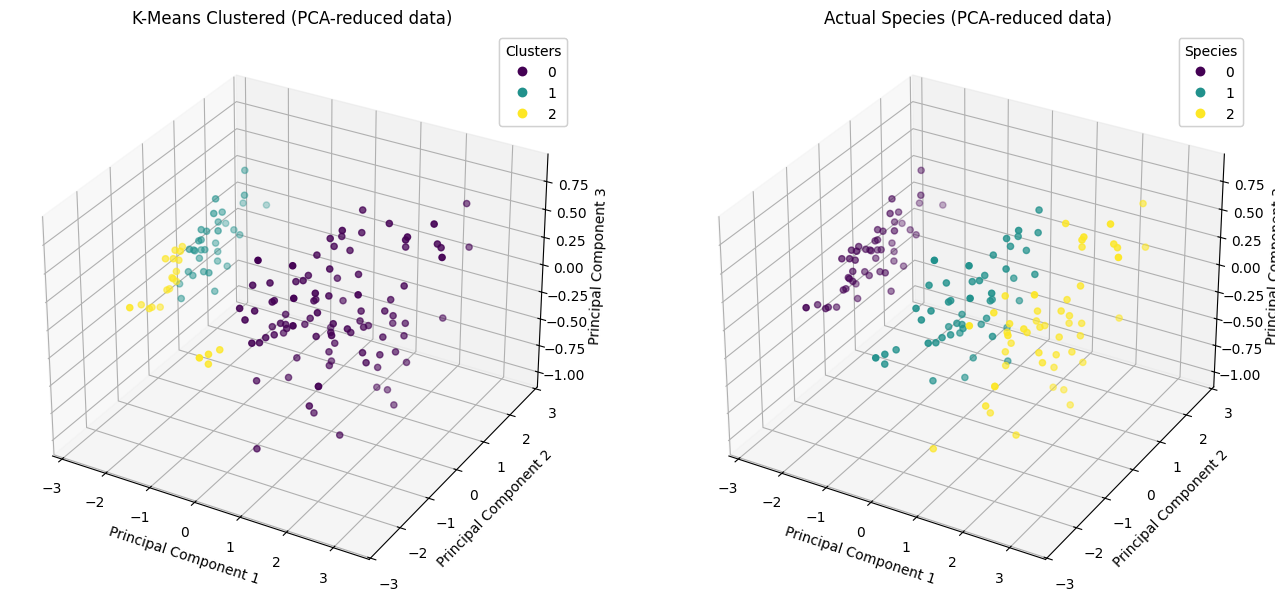

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

# Perform PCA to reduce dimensions to 3
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_pca)

# Predicted clusters and true labels
clusters = kmeans.labels_

# Plotting the results of PCA reduction with K-Means clustering
fig = plt.figure(figsize=(16, 8))

# 3D scatter plot for clusters
ax = fig.add_subplot(121, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, cmap='viridis', label=iris['species'].unique())
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
ax.set_title('K-Means Clustered (PCA-reduced data)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# 3D scatter plot for true labels
ax = fig.add_subplot(122, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=pd.Categorical(iris['species']).codes, cmap='viridis')
legend2 = ax.legend(*scatter.legend_elements(), title="Species")
ax.add_artist(legend2)
ax.set_title('Actual Species (PCA-reduced data)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

plt.show()



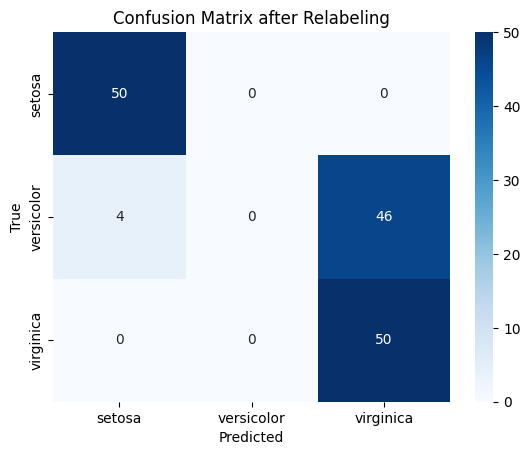

New Accuracy: 0.67


In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'clusters' is the array of cluster assignments from K-Means
# Assuming 'y' is the actual labels from the Iris dataset

# Create a DataFrame to help with mapping
mapping_df = pd.DataFrame({'predicted_cluster': clusters, 'true_label': y})

# Find the most common true label for each cluster
def most_common_label(x):
    return x.value_counts().idxmax()

cluster_to_species = mapping_df.groupby('predicted_cluster')['true_label'].agg(most_common_label).to_dict()

# Map predicted clusters to actual species labels
mapped_predictions = np.array([cluster_to_species[cluster] for cluster in clusters])

# Calculate accuracy and confusion matrix
new_accuracy = accuracy_score(y, mapped_predictions)
new_cm = confusion_matrix(y, mapped_predictions, labels=iris['species'].unique())

# Plot new confusion matrix
sns.heatmap(new_cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris['species'].unique(), yticklabels=iris['species'].unique())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix after Relabeling')
plt.show()

print(f"New Accuracy: {new_accuracy:.2f}")
